In [4]:
# визуализация траектории
# светового луча в среде
# с неоднородным коэффициентом преломления

# Ячейка № 1

# подключение библиотеки numpy
import numpy as np

# подключение пакета matplotlib.pyplot
import matplotlib.pyplot as plt


In [5]:
# Ячейка № 2

# задание функции, возвращающей
# значение коэффициента рефракции
def Coeff_Refraction(y):
    return np.sqrt(1 + 4 * y)


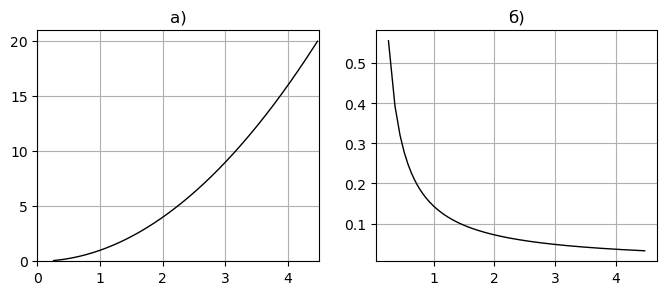

In [6]:
# Ячейка № 3

# задание значений координат
# левого и правого концов
# отрезка интегрирования
Y_min = 10**-5
Y_max = 20

# задание числа интервалов
# разбиения отрезка интегрирования
Np = 300

# задание числа узлов сетки,
# используемой для вычисления
# численного значения интеграла
# на соответствующем интервале
# отрезка интегрирования
Nk = 10**3

# инициализация массивов, используемых
# для вычисления значений интеграла как
# функции с переменным верхним пределом
# в соответствие с (9.112)
Z = np.zeros(Nk)
Xb = np.zeros(Np - 1)
Yb = np.zeros(Np - 1)
Z = np.zeros(Nk)


# инициализация массива, используемого для
# хранения координат узлов сетки,
# вычисляемых на соответствующем интервале
# отрезка интегрирования
y = np.linspace(Y_min, Y_max, Np)

Su = 0
# вычисление значений интеграла в (9.112)
# как функции с переменным верхним пределом
for i in range(Np - 1):
    Y = np.linspace(y[i], y[i + 1], Nk)
    for k in range(Nk):
        Z[k] = 1 / np.sqrt(Coeff_Refraction(Y[k]) ** 2 - 1)
    Xb[i] = Su + np.trapz(Z, Y)
    Su = Xb[i]
    Yb[i] = Y[Nk - 1]

#  визуализация траектории
# светового луча и относительной
# погрешности ее вычисления

fig = plt.figure(figsize=(8, 3))

# визуализация траектории луча,
# вычисленной численно
plt.subplot(1, 2, 1)
plt.plot(Xb, Yb, "-k", lw=1)
plt.title("а)")
plt.grid(True)
plt.xlim([0, 4.5])
plt.ylim([0, 21])

# визуализация относительной
# погрешности вычисления
# траектории луча
plt.subplot(1, 2, 2)
plt.plot(
    np.sqrt(Yb[:]), np.abs(np.sqrt(Yb[:]) - Xb[:]) / np.sqrt(Yb[:]) * 10**2, "-k", lw=1
)
plt.title("б)")
plt.grid(True)

plt.show()